<a href="https://colab.research.google.com/github/tayibaabdulrasool1-del/Sales_dataset/blob/main/HR_Analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition (1).csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [3]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df["Department"].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [9]:
df["Gender"].value_counts()

,count
Gender,
Male,882
Female,588


#1.What factors cause employee attrition?

In [10]:
df = df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"],
    axis=1,
    errors="ignore"   # <- this ensures no KeyError even if column missing
)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [11]:
df["Attrition_num"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["OverTime_num"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [12]:
numeric_cols = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome",
                "YearsAtCompany", "Attrition_num", "OverTime_num"]

arr = df[numeric_cols].to_numpy(dtype=float)

In [13]:
df[["Attrition_num","DailyRate"]].corr()

,Attrition_num,DailyRate
Attrition_num,1.000000,-0.056652
DailyRate,-0.056652,1.000000


In [14]:
df[["Attrition_num","Age"]].corr()

,Attrition_num,Age
Attrition_num,1.000000,-0.159205
Age,-0.159205,1.000000


In [15]:
df[["Attrition_num","OverTime_num"]].corr()

,Attrition_num,OverTime_num
Attrition_num,1.000000,0.246118
OverTime_num,0.246118,1.000000


In [16]:
df[["Attrition_num","HourlyRate"]].corr()

,Attrition_num,HourlyRate
Attrition_num,1.000000,-0.006846
HourlyRate,-0.006846,1.000000


In [17]:
df[["Attrition_num","DistanceFromHome"]].corr()

,Attrition_num,DistanceFromHome
Attrition_num,1.000000,0.077924
DistanceFromHome,0.077924,1.000000


In [18]:
df[["Attrition_num","JobSatisfaction"]].corr()

,Attrition_num,JobSatisfaction
Attrition_num,1.000000,-0.103481
JobSatisfaction,-0.103481,1.000000


In [19]:
df[["Attrition_num","MonthlyIncome"]].corr()

,Attrition_num,MonthlyIncome
Attrition_num,1.00000,-0.15984
MonthlyIncome,-0.15984,1.00000


In [20]:
df[["Attrition_num","YearsAtCompany"]].corr()

,Attrition_num,YearsAtCompany
Attrition_num,1.000000,-0.134392
YearsAtCompany,-0.134392,1.000000


In [21]:
df.groupby("BusinessTravel")["Attrition_num"].mean()


,Attrition_num
BusinessTravel,
Non-Travel,0.080000
Travel_Frequently,0.249097
Travel_Rarely,0.149569


In [22]:
df.groupby("Department")["Attrition_num"].mean()

,Attrition_num
Department,
Human Resources,0.190476
Research & Development,0.138398
Sales,0.206278


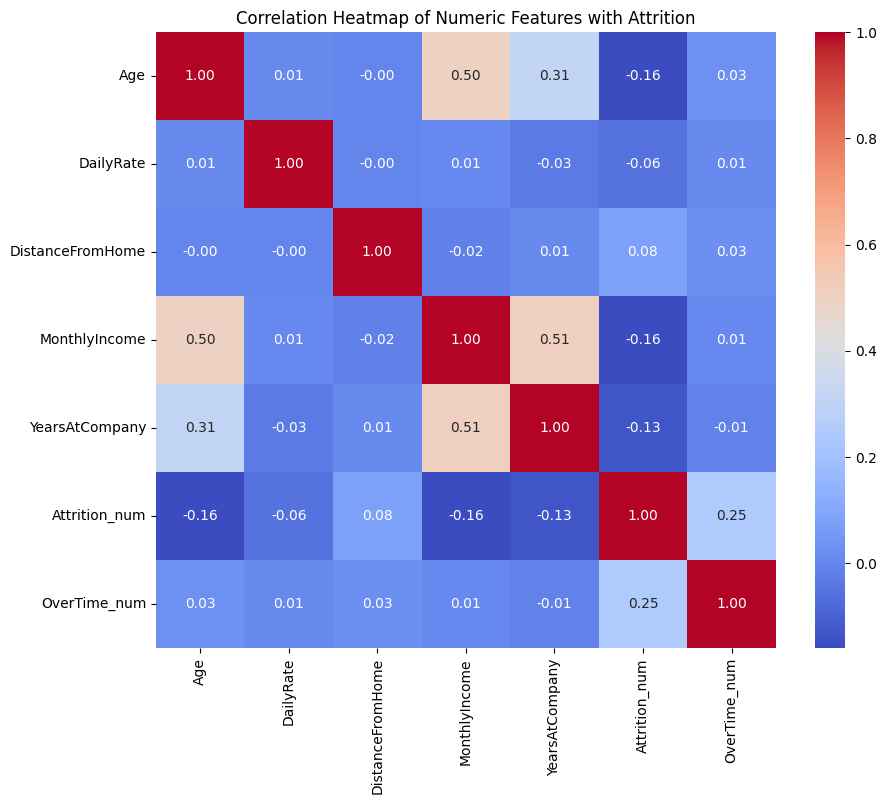

In [23]:
from numpy._core import numeric
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features with Attrition")
plt.show()

# 2.Which departments have highest turnover?

In [24]:
df.groupby("Department")["MonthlyIncome"].sum().sort_values(ascending=False)

,MonthlyIncome
Department,
Research & Development,6036284
Sales,3103791
Human Resources,419234


# 3.Which departments have highest turnover

In [25]:
df.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=False)

,MonthlyIncome
Department,
Sales,6959.172646
Human Resources,6654.507937
Research & Development,6281.252862


## 4.What factors cause employee attrition?

In [26]:
df[["Attrition_num","OverTime_num"]].corr()

,Attrition_num,OverTime_num
Attrition_num,1.000000,0.246118
OverTime_num,0.246118,1.000000


# 5.How does job satisfaction impact resignations?

In [27]:
df[["Attrition_num","JobSatisfaction"]].corr()

,Attrition_num,JobSatisfaction
Attrition_num,1.000000,-0.103481
JobSatisfaction,-0.103481,1.000000


# 6.Is there gender pay gap?

In [28]:
gender_pay_gap = df.groupby("Gender")["MonthlyIncome"].mean()
gender_pay_gap

,MonthlyIncome
Gender,
Female,6686.566327
Male,6380.507937


# 7. Which experience range leaves most?

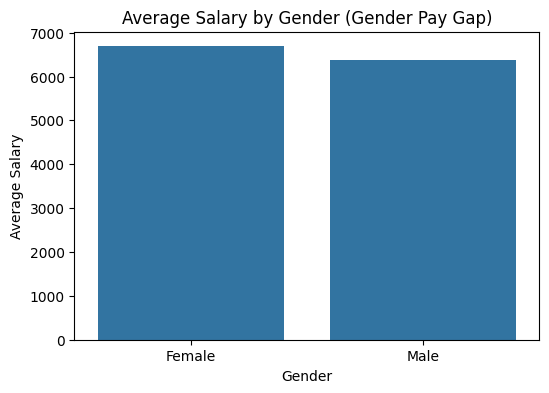

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(x=gender_pay_gap.index, y=gender_pay_gap.values)
plt.ylabel("Average Salary")
plt.title("Average Salary by Gender (Gender Pay Gap)")
plt.show()

In [30]:
df.groupby("Department")["TotalWorkingYears"].mean().sort_values(ascending=False)

,TotalWorkingYears
Department,
Human Resources,11.555556
Research & Development,11.342352
Sales,11.105381


# Countplot → Attrition distribution

In [31]:
# <!-- What this graph tells? -->

# <!-- Total employees who left the company -->

# <!-- Total employees who stayed -->

# If 1200 = No and 270 = Yes, then attrition rate is relatively low.

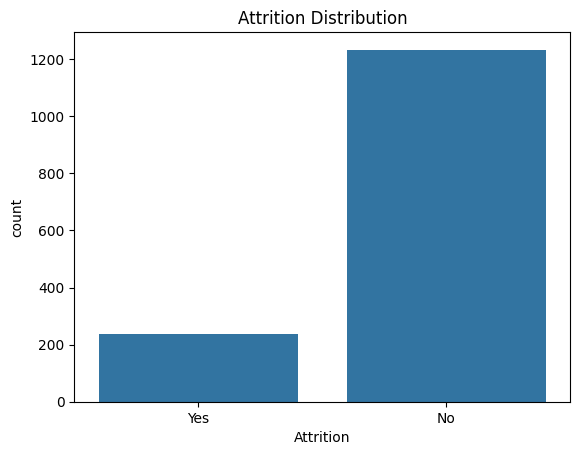

In [32]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

# Bar chart → Attrition by department

In [33]:
# Attrition = Yes → employees who left

# Attrition = No → employees who stayed

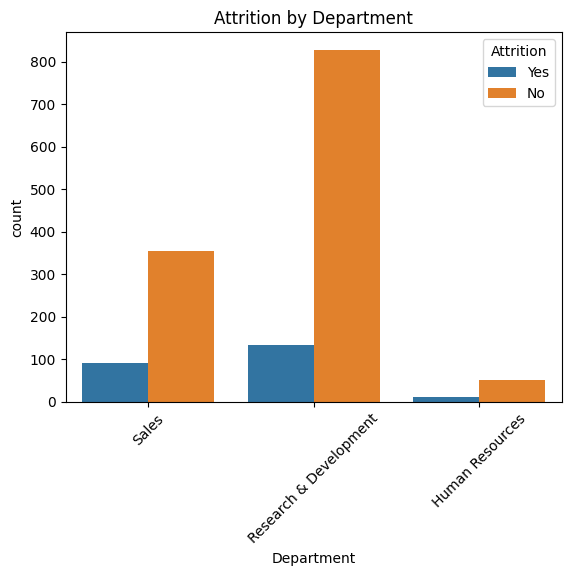

In [34]:
sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

# Boxplot → Salary vs Attrition

In [35]:
# Employees who left may have lower median salary

# Employees who stayed may have higher income

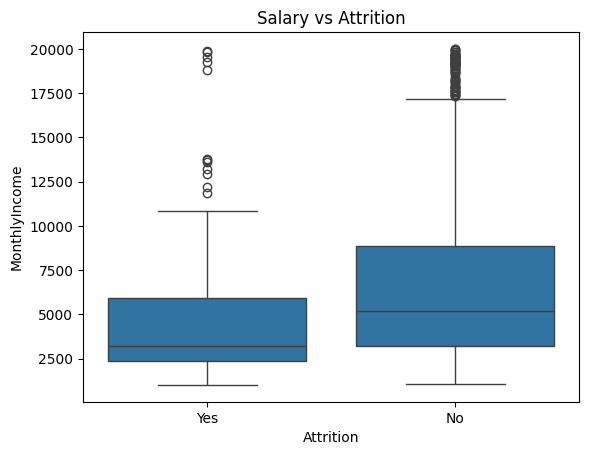

In [36]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Salary vs Attrition")
plt.show()


# Histogram → Years at company

In [37]:
# If most employees are 0–2 years, the company may have high turnover.

# If many employees are 10+ years, the company has good retention.

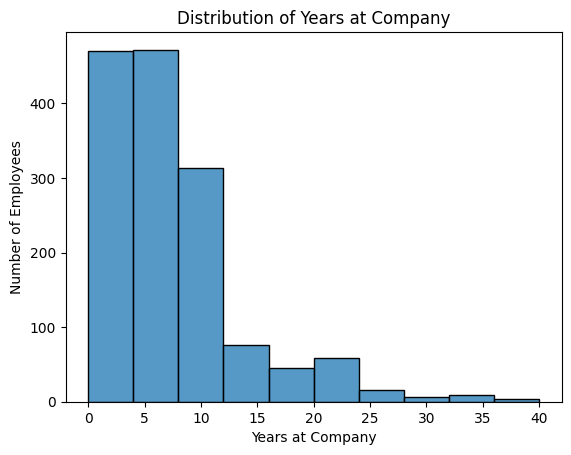

In [38]:
sns.histplot(df["YearsAtCompany"], bins=10)

plt.title("Distribution of Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.show()